# **STUDI KASUS**

### Analisis Kinerja Penjualan dan Retur pada E-Commerce

# **Import Library**

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading Datasets**

In [89]:
path = "/content/ecommerce_sales_dataset.csv"
df = pd.read_csv(path)

print("Ukuran data (baris & kolom): ", df.shape, "\n")

df

Ukuran data (baris & kolom):  (5000, 18) 



,Transaction_ID,Date,Customer_ID,Product,Quantity,Payment_Method,Country,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Return_Status,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total,Category
0,TXN_0004163,2023-01-01,CUST_00662,Router,6,Credit Card,India,0,5.0,19.0,5.0,No,247,1482,0.00,1482.00,1487.00,Networking
1,TXN_0003251,2023-01-01,CUST_00522,Hard Drive,6,Credit Card,USA,5,15.0,10.0,5.0,No,214,1284,64.20,1219.80,1234.80,Storage
2,TXN_0001138,2023-01-01,CUST_00941,Charger,3,Credit Card,USA,0,10.0,29.0,5.0,Yes,105,315,0.00,315.00,325.00,Accessories
3,TXN_0002035,2023-01-01,CUST_00799,Speaker,5,Apple Pay,USA,5,5.0,NaN,4.0,Yes,189,945,47.25,897.75,902.75,Accessories
4,TXN_0000649,2023-01-01,CUST_00388,Monitor,3,Debit Card,USA,5,25.0,25.0,NaN,No,466,1398,69.90,1328.10,1353.10,Peripherals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TXN_0004302,2024-12-31,CUST_00785,Hard Drive,5,Debit Card,Australia,0,10.0,9.0,NaN,No,217,1085,0.00,1085.00,1095.00,Storage
4996,TXN_0001668,2024-12-31,CUST_00712,Mouse,8,Credit Card,Japan,0,5.0,9.0,2.0,No,29,232,0.00,232.00,237.00,Peripherals
4997,TXN_0002446,2024-12-31,CUST_00112,Keyboard,6,Credit Card,USA,0,15.0,20.0,5.0,No,149,894,0.00,894.00,909.00,Peripherals
4998,TXN_0001326,2024-12-31,CUST_00220,Webcam,9,Debit Card,Germany,0,20.0,20.0,4.0,No,111,999,0.00,999.00,1019.00,Peripherals


# **Business Understanding**

### Business Objective

Perusahan e-commerce ingin memahami kinerja penjualan selama 2023 hingga 2024 secara menyeluruh. Fokus utamanya adalah mengukur pertumbuhannya pendapatan, mengidentifikasi kategori dan produk dengan kontribursi tinggi. Lalu memahami faktir hubungannya dengan tingginya tingkat retur. Selain itu juga, perusahaan ingin adanya evaluasi strategi diskon, biaya pengiriman, dan waktu pengiriman terhadap kepuasan customer yang bisa diliat dengan rating. Hasil analisis ini diharapkan untuk menjadi dasar keputusan strategis sebuah perusahaan untuk meningkatkan kualitas dan pengalaman customer.

---



### Asses Situation

Datasets terdapat ada 5000 transaksi dengan rentang waktu 2 tahun dari 2023 hingga 2024. Pada datasets tersebut mencakup 15 jenis produk, 5 jenis kategori, dan 8 jenis negara. Lalu total pendapatannya mencapai 6.537.440,25. Beberapa kolom juga memiliki *missing value* pada Delivery_Days dan juga Customer_Rating. Dapat dilihat kondisi tersebut dapat diperhatikan dalam proses analisa karena dapat memengaruhi hasil. Karena dengan kosongnya data pada Delivery_Days dan Customer_Rating dapat memengaruhi analisa data lain yang memiliki hubungan dengan waktu pengiriman, kepuasan customer, dan retur.

Tantangan tersebut perlu dipahami agar hasil analisa tetap realitis dan valid sesuai dengan data yang ada.


---



In [90]:
print("Jumlah jenis produk pada transaksi:", df["Product"].nunique(), "\n")
print("Berikut daftar produknya:")
df["Product"].drop_duplicates()

Jumlah jenis produk pada transaksi: 15 

Berikut daftar produknya:


,Product
0,Router
1,Hard Drive
2,Charger
3,Speaker
4,Monitor
5,USB Cable
6,Headphones
9,Microphone
12,Mouse
13,Keyboard


In [91]:
print("Jumlah jenis kategori pada transaksi:", df["Category"].nunique(), "\n")
print("Berikut daftar kategorinya:")
df["Category"].drop_duplicates()

Jumlah jenis kategori pada transaksi: 5 

Berikut daftar kategorinya:


,Category
0,Networking
1,Storage
2,Accessories
4,Peripherals
27,Electronics


In [92]:
print("Jumlah jenis negara pada transaksi:", df["Country"].nunique(), "\n")
print("Berikut daftar negaranya:")
df["Country"].drop_duplicates()

Jumlah jenis negara pada transaksi: 8 

Berikut daftar negaranya:


,Country
0,India
1,USA
5,Germany
8,UK
9,Canada
11,Japan
14,Australia
19,France


In [93]:
print( "Berikut hasil total pendapatan pada datasets tersebut: ", df["Final_Total"].sum())

Berikut hasil total pendapatan pada datasets tersebut:  6537440.25


### Analytic Goals

Tujuan dari analisa ini agar dapat mengidentifikasi tren pendapatan dan membandingkan performa. Analisa ini juga dilakukan agar dapat mengevaluasi kontribusi per-kategori dan produk terhadap total pendapatan dan tingkat retur. Hubungan antar diskon, nilai transaksi, biaya pengiriman, dan waktu pengiriman terhadap retur akan dianalisa lebih lanjut untuk menemukan pola risiko pada data tersebut. Selain itu, analisa rating customer akan digunakan untuk memahami faktor yang memengaruhi kepuasan dan loyalitas. Hasil akhir dari tujuan ini diharapkan dapat mampu menghasilkan *insight* yang dapat di eksekusi (action) oleh manajemen.

---



### Project Plan

Rencana projek ini dimulai dengan data *loading* dan pemeriksaaan kualitas data untuk memastikan konsistensi dan struktural dataset. Tahap berikutnya adalah dengan melakukan pembersihan data, termasuk konversi tipe tanggal, dan penanganan *missing value*. Selanjutnya mengeksplorasi data dilakukan untuk memahami distribusi nilai transaksi, diskon, ongkos pengiriman, dan *delivery days*. Lalu visualisasi akan digunakan untuk menampilkan tren pendaoatan, kontribusi per kategori dan produk, serta analisa retur. Terakhir yaitu implementasi dari insight dan penyusunan rekomendasi strategi bisnis yang relevan berdasarkan analisis.

---



# **Data Understanding**

### Struktur Data

In [94]:
print("Berikut untuk struktur data datasets:", "\n")
df.info()

Berikut untuk struktur data datasets: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction_ID               5000 non-null   object 
 1   Date                         5000 non-null   object 
 2   Customer_ID                  5000 non-null   object 
 3   Product                      5000 non-null   object 
 4   Quantity                     5000 non-null   int64  
 5   Payment_Method               5000 non-null   object 
 6   Country                      5000 non-null   object 
 7   Discount_Percentage          5000 non-null   int64  
 8   Shipping_Cost                5000 non-null   float64
 9   Delivery_Days                4768 non-null   float64
 10  Customer_Rating              4750 non-null   float64
 11  Return_Status                5000 non-null   object 
 12  Unit_Price                   5000 no

1. Transaction_ID:
        Jumlah baris: 5000
        Tipe data: object
        Deskripsi: ID unik untuk setiap transaksi

2. Date:
        Jumlah baris: 5000
        Tipe data: object
        Deskripsi: Tanggal transaksi

3. Customer_ID:
        Jumlah baris: 5000
        Tipe data: object
        Deskripsi: ID unik pelanggan

4. Product:
        Jumlah baris: 5000
        Tipe data: object
        Deskripsi: Nama produk yang dibeli

5. Quantity:
        Jumlah baris: 5000
        Tipe data: int64
        Deskripsi: Jumlah unit yang dibeli dalam satu transaksi

6. Payment_Method:
        Jumlah baris: 5000
        Tipe data: object
        Deskripsi: Metode pembayaran yang digunakan

7. Country:
        Jumlah baris: 5000
        Tipe data: object
        Deskripsi: Negara asal transaksi

8. Discount_Percentage:
        Jumlah baris: 5000
        Tipe data: int64
        Deskripsi: Persentase diskon yang diberikan

9. Shipping_Cost:
        Jumlah baris: 5000
        Tipe data: float64
        Deskripsi: Biaya pengiriman

10. Delivery_Days:
        Jumlah baris: 4768
        Tipe data: float64
        Deskripsi: Lama waktu pengiriman

11. Customer_Rating:
        Jumlah baris: 4750
        Tipe data: float64
        Deskripsi: Rating yang diberikan customer

12. Return_Status:
        Jumlah baris: 5000
        Tipe data: object
        Deskripsi: Status pengembalian barang

13. Unit_Price:
        Jumlah baris: 5000
        Tipe data: int64
        Deskripsi: Harga satuan produk

14. Total_Price_Before_Discount:
        Jumlah baris: 5000
        Tipe data: int64
        Deskripsi: Total harga sebelum diskon

15. Discount_Amount:
        Jumlah baris: 5000
        Tipe data: float64
        Deskripsi: Jumlah nominal diskon

16. Price_After_Discount:
        Jumlah baris: 5000
        Tipe data: float64
        Deskripsi: Harga setelah diskon sebelum biaya tambahan

17. Final_Total:
        Jumlah baris: 5000
        Tipe data: float64
        Deskripsi: Total akhir yang dibayarkan customer

18. Category:
        Jumlah baris: 5000
        Tipe data: object
        Deskripsi: Kategori produk

### Statistik Deskriptif

In [95]:
print("Berikut merupakan statistik deskriptif datasets:")
df.describe()

Berikut merupakan statistik deskriptif datasets:


,Quantity,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total
count,5000.000000,5000.000000,5000.000000,4768.000000,4750.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,4.979600,5.022000,12.592000,15.185822,4.130947,272.908000,1365.791800,70.89575,1294.896050,1307.488050
std,2.561347,6.173908,7.589668,8.367771,1.119756,293.120632,1793.381955,170.69200,1701.676309,1701.813429
min,1.000000,0.000000,0.000000,1.000000,1.000000,-38.000000,-315.000000,-36.40000,-315.000000,-300.000000
25%,3.000000,0.000000,5.000000,8.000000,4.000000,86.000000,274.000000,0.00000,260.225000,273.750000
50%,5.000000,0.000000,15.000000,15.000000,4.000000,156.000000,742.000000,0.00000,699.250000,710.700000
75%,7.000000,10.000000,20.000000,23.000000,5.000000,370.250000,1512.000000,62.40000,1449.700000,1461.750000
max,9.000000,20.000000,25.000000,29.000000,5.000000,1099.000000,9891.000000,1789.20000,9693.000000,9718.000000


**1.   Count**

      Dapat dilihat dari statistik deskriptif tersebut
      menunjukkan sebagian besar memiliki 5000 baris tapi

      *   Delivery_Days hanya 4768 baris
      *   Customer_Rating hanya 4750 baris

      Hal ini menunjukkan adanya missing values pada kedua kolom tersebut.

**2.   Mean vs Median**

*   Quantity

    *   Mean: 4,98
    *   Median: 5
    
    Nilai rata-rata hampir sama dengan nilai mediannya menunjukkan distribusinya relatif simetris yang berarti mayoritas customer membeli sekitar 5 item per transaksi.


*   Discount_Percentage

    *   Mean: 5,02
    *   Median: 0

    Dengan nilai median 0 menunjukkan 50% atau lebih transaksi tidak mendapatkan diskon. Namun rata-ratanya 5% menunjukkan adanya sebagaian transaksi mendapatkan diskon besar.

*   Unit_Price

    *   Mean: 272,91
    *   Median: 156

    Nilai rata-rata jauh lebih tinggi dari nilai median menunjukkan adanya produk dengan harga sangat tinggi yang memengaruhi rata-rata.

*   Final Total

    *   Mean: 1307,49
    *   Median: 710,7

    Dapat dilihat sebagian besar transaksi memiliki nilai di sekitar 710,7, tetapi terdapat sejumlah transaksi bernilai sangat besar yang menarik rata-rata naik hingga 1307,49.


**3.   Min & Max**

*   Quantity

    *   Min: 1
    *   Max: 9
    
    Rentang tersebut cukup realistis yang berarti tidak ada pembelian dalam jumlah extrem.


*   Discount_Percentage

    *   Min: 0%
    *   Max: 20%

    Hal itu menunjukkan bahwa diskon terjadi antara 0% hingga 20% yang dimana cukup normal.

*   Unit_Price

    *   Min: -38
    *   Max: 1099

    Nilai minimum negatif (-38) tidak logis untuk harga satuan produk yang kemungkinan terjadi adalah kesalahan input data atau produk refund.

*   Total_Price_Before_Discount

    *   Min: -315
    *   Max: 9891

    Nilai negatif menunjukkan adanya transaksi refund atau koreksi transaksi dan nilai maksimum hampir 10.000 menunjukkan adanya transaksi bernilai sangat besar.


**4.   Standar Deviasi (std) - Variabilitas Data**

*   Quantity

    *   Mean: 4,98
    *   Std: 2,56
    
    Standar deviasi sekitar beda setengah dari mean, menunjukkan variasi pembelian cukup moderat.


*   Total_Price_Before_Discount

    *   Mean: 1365,79
    *   Std: 1793,38

    Standar deviasi jauh lebih besar dari mean. Ini menunjukkan nilai transaksi sangat tidak stabil dan terdapat transaksi ekstrem bernilai sangat tinggi

*   Unit_Price

    *   Mean: 272,91
    *   Std: 293,12

    Standar deviasi lebih besar dari mean, menunjukkan variasi harga produk sangat tinggi.

*   Final Total

    *   Mean: 1307,49
    *   Std: 1701,67

    Variasi nilai akhir transaksi sangat besar.
---



### Tipe Data

In [96]:
print("Berikut untuk meriksa tipe data setiap kolom pada datasets:")
df.dtypes

Berikut untuk meriksa tipe data setiap kolom pada datasets:


,0
Transaction_ID,object
Date,object
Customer_ID,object
Product,object
Quantity,int64
Payment_Method,object
Country,object
Discount_Percentage,int64
Shipping_Cost,float64
Delivery_Days,float64


Dapat dilihat tipe data dari semua kolom sudah sesuai kecuali pada kolom Date yang bertipe data object yang harusnya tipe datanya Date bukan Object. Pengecekan ini dilakukan agar saat ngevisualisasi serta insight yang akan dibuat itu akurat.

---



### Incosistent Values

**1.   Date**


In [97]:
print("Berikut untuk meriksa Incosistent Values Pada Kolom Date:")
print(df['Date'].unique())

Berikut untuk meriksa Incosistent Values Pada Kolom Date:
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10'
 '2023-01-11' '2023-01-12' '2023-01-13' '2023-01-14' '2023-01-15'
 '2023-01-16' '2023-01-17' '2023-01-18' '2023-01-19' '2023-01-20'
 '2023-01-21' '2023-01-22' '2023-01-23' '2023-01-24' '2023-01-25'
 '2023-01-26' '2023-01-27' '2023-01-28' '2023-01-29' '2023-01-30'
 '2023-01-31' '2023-02-01' '2023-02-02' '2023-02-03' '2023-02-04'
 '2023-02-05' '2023-02-06' '2023-02-07' '2023-02-08' '2023-02-09'
 '2023-02-10' '2023-02-11' '2023-02-12' '2023-02-13' '2023-02-14'
 '2023-02-15' '2023-02-16' '2023-02-17' '2023-02-18' '2023-02-19'
 '2023-02-20' '2023-02-21' '2023-02-22' '2023-02-23' '2023-02-24'
 '2023-02-25' '2023-02-26' '2023-02-27' '2023-02-28' '2023-03-01'
 '2023-03-02' '2023-03-03' '2023-03-04' '2023-03-05' '2023-03-06'
 '2023-03-07' '2023-03-08' '2023-03-09' '2023-03-10' '2023-03-11'
 '2023-03-12' '202

Dapat dilihat pada kolom Date saat diperiksa *Incosistent Values*-nya, bahwa kolom tersebut konsisten datanya, jadi pada kolom tersebut
aman karena tidak memiliki *Incosistent Values.* Dapat dilihat dari outputnya semua data yang formatnya konsisten menggunakan (yyyy/mm/dd), dengan menggunakan numerik semua.

---



**1.   Category**


In [98]:
print("Berikut untuk meriksa Incosistent Values Pada Kolom Category:")
print(df['Category'].unique())

Berikut untuk meriksa Incosistent Values Pada Kolom Category:
['Networking' 'Storage' 'Accessories' 'Peripherals' 'Electronics']


Dapat dilihat pada kolom Category saat diperiksa *Incosistent Values*-nya, bahwa kolom tersebut konsisten datanya, jadi pada kolom tersebut
aman karena tidak memiliki *Incosistent Values.* Dapat dilihat dari outputnya: Networking, Storage, Accessories, Peripherals, dan Electronics. Dari segi penulisan per satu kata sudah konsisten.

---



### Missing Values

In [99]:
print("Berikut merupakan jumlah missing value per kolomnya:")
pd.DataFrame(df.isna().sum())

Berikut merupakan jumlah missing value per kolomnya:


,0
Transaction_ID,0
Date,0
Customer_ID,0
Product,0
Quantity,0
Payment_Method,0
Country,0
Discount_Percentage,0
Shipping_Cost,0
Delivery_Days,232


Dapat dilihat dari output tersebut menunjukkan baha pada kolom Delivery_Days dan Customer_Rating memiliki missing values yang cukup besar.


1.   Delivery_Days missing values: 232
2.   Customer_Rating missing values: 250



---



### Duplicated Values

In [100]:
df[df.duplicated()]

,Transaction_ID,Date,Customer_ID,Product,Quantity,Payment_Method,Country,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Return_Status,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total,Category


Berdasarkan pada output tersebut tidak ditemukan data yang terduplikasi secara keseluruhan pada datasetsnya.

---



### Outlier Values

In [101]:
print("Berikut merupakan menampilkan jumlah outliers per kolom:")

results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers))
  results.append({'Kolom': col, 'Jumlah Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Berikut merupakan menampilkan jumlah outliers per kolom:


Kolom,Jumlah Outliers
Quantity,0
Discount_Percentage,0
Shipping_Cost,0
Delivery_Days,0
Customer_Rating,489
Unit_Price,570
Total_Price_Before_Discount,585
Discount_Amount,636
Price_After_Discount,575
Final_Total,576


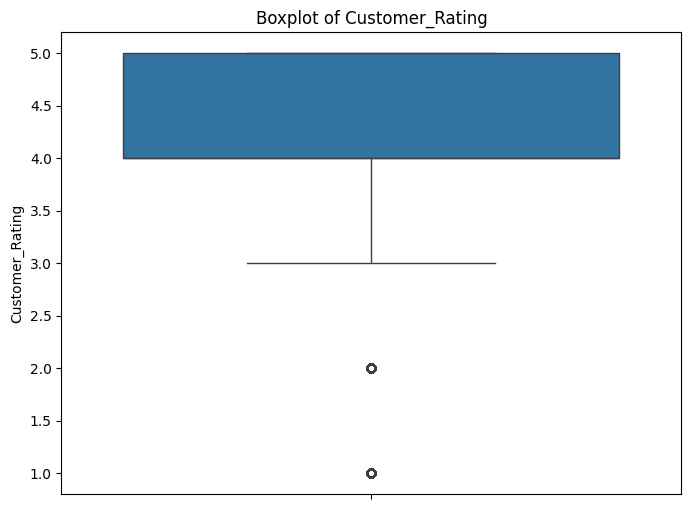

In [102]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Customer_Rating'])
plt.title('Boxplot of Customer_Rating')
plt.ylabel('Customer_Rating')
plt.show()

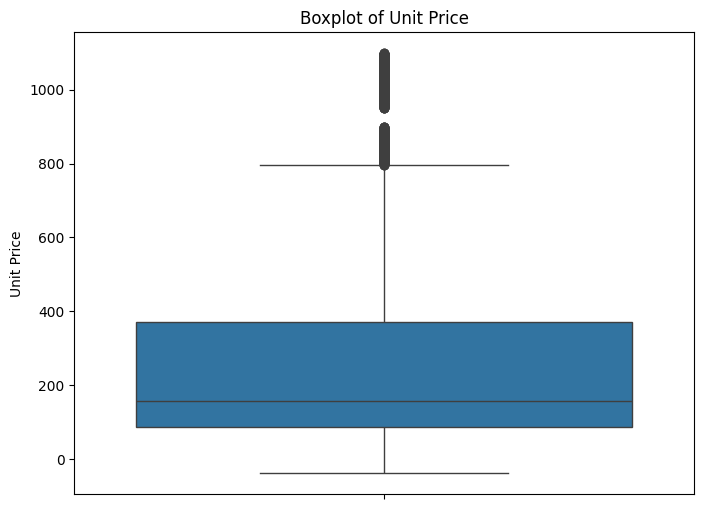

In [103]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Unit_Price'])
plt.title('Boxplot of Unit Price')
plt.ylabel('Unit Price')
plt.show()

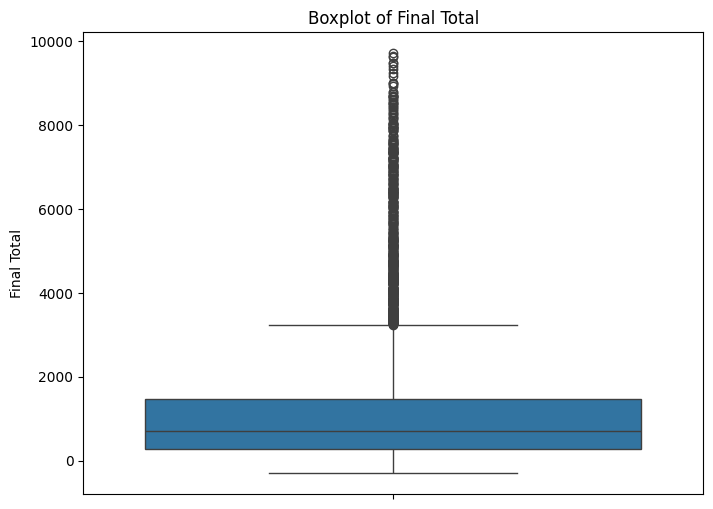

In [104]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Final_Total'])
plt.title('Boxplot of Final Total')
plt.ylabel('Final Total')
plt.show()

Dapat dilihat dari hasilnya pada kolom Customer_Rating, Unit_Price, Total_Price_Before_Discount, Discount_Amount, Price_After_Discount, Final_total memiliki jumlah outlier yang cukup tinggi. Hal ini menunjukkan adanya transaksi dengan nilai harganya atau final total yang jauh lebih besar dibandingkan mayoritas transaksi yang lain.

---



# **Exploratory Data Analysis (EDA)**

### Comparison

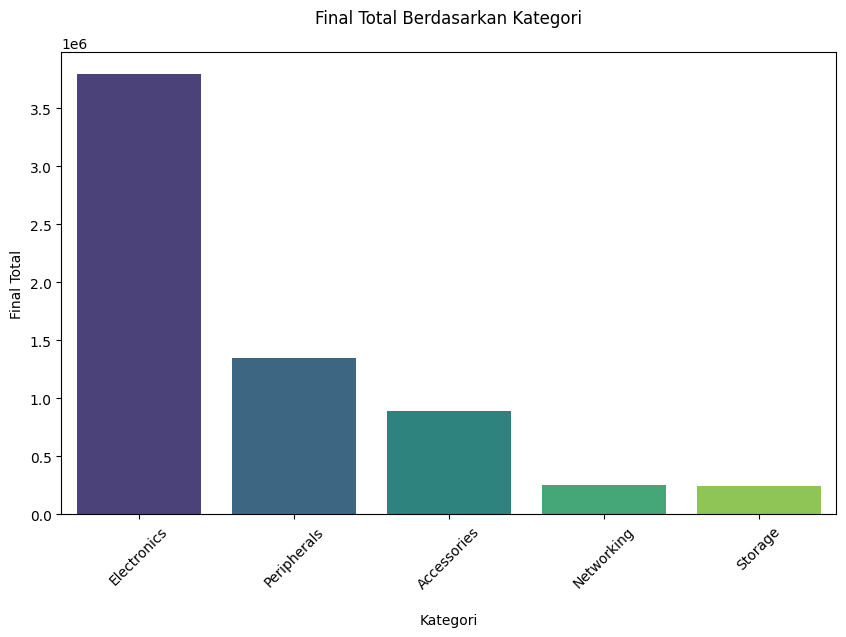

In [105]:
penjualan_market = df.groupby('Category')['Final_Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penjualan_market.index, y=penjualan_market.values, palette='viridis', hue=penjualan_market.index, legend=False)
plt.title('Final Total Berdasarkan Kategori\n')
plt.xlabel('\nKategori')
plt.ylabel('Final Total')
plt.xticks(rotation=45)
plt.show()


Dapat dilihat dari grafik diatas menggambarkan perbandingan antar kategori berdasarkan jumlah final total. Dari grafik tersebut dapat dilihat perbandingannya bahwa kategori Electronics jauh lebih dominan dibandingkan kategori yang lain, hal ini menunjukkan besarnya ketimpangan penjualan berdasarkan kategori yang dimana kategori yang lain memiliki jumlah yang kecil.

---



### Composition

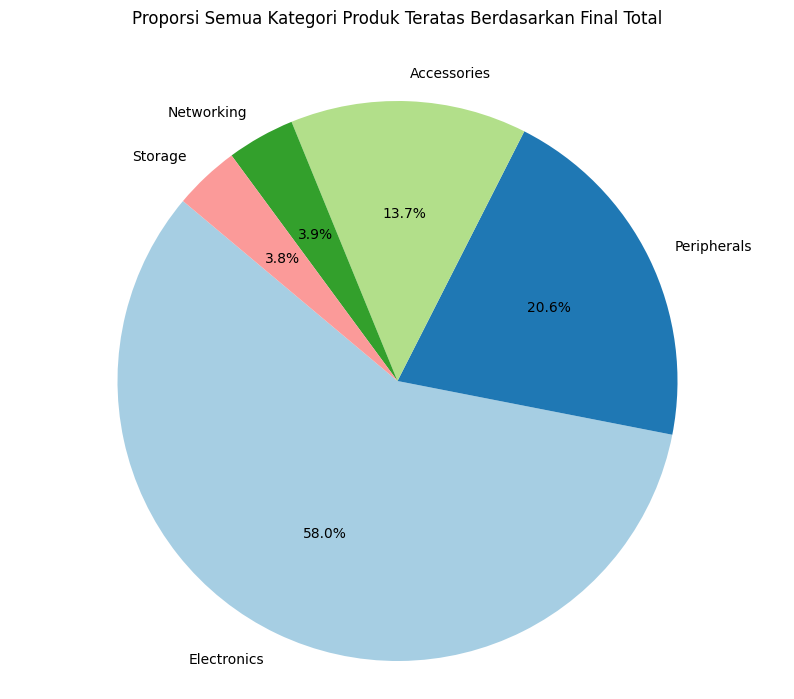

In [106]:
sales_by_category = df.groupby('Category')['Final_Total'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sales_by_category.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi Semua Kategori Produk Teratas Berdasarkan Final Total\n\n')
plt.ylabel('')
plt.axis('equal')
plt.show()


Dari komposisi grafik diatas menunjukkan bahwa pada kategori *Electronics* menyumbangkan lebih dari separuh dari final total nilai transaksi. Hal ini menunjukkan bahwa pendapatan dari datasets tersebut bergantung pada satu kategori utama, sedangkan yang lainnya hanya berkontribusi dalam proporsi yang kecil.

---



### Distribution

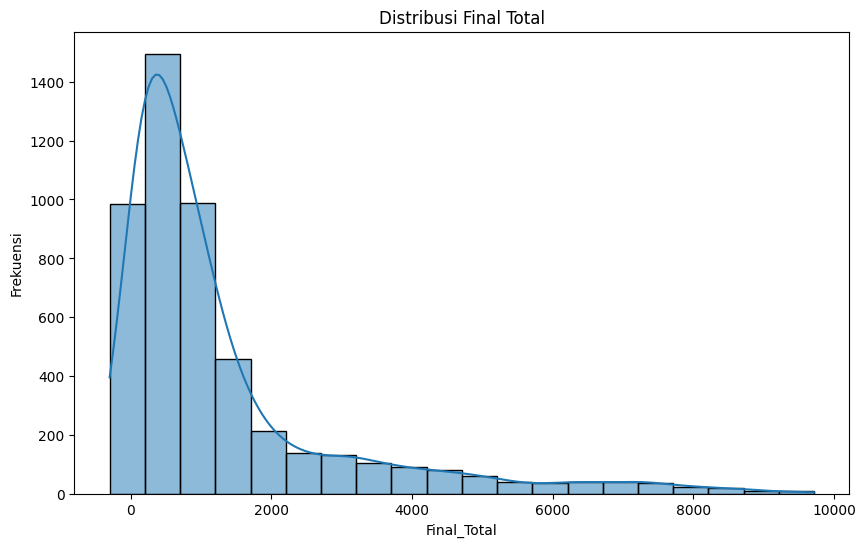

In [107]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Final_Total'], bins=20, kde=True)
plt.title('Distribusi Final Total')
plt.xlabel('Final_Total')
plt.ylabel('Frekuensi')
plt.show()


Dapat dilihat pada grafik histogram tersebut menunjukkan bahwa transaksi dengan nilai rendah jauh lebih tinggi dibandingkan transaksi bernilai tinggi.

---



### Relationship

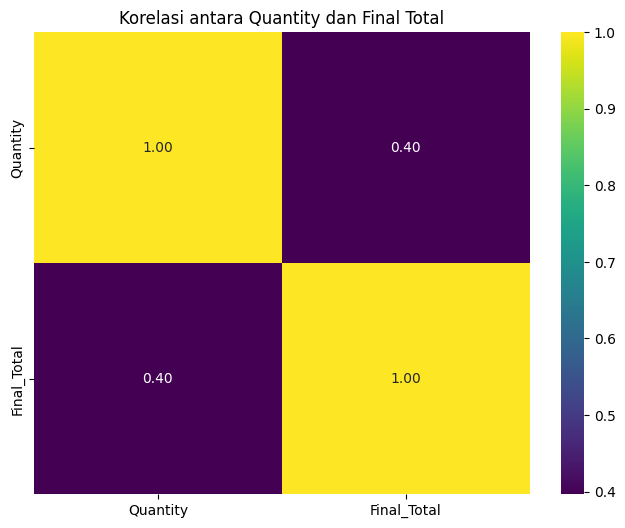

In [108]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Quantity', 'Final_Total']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Quantity dan Final Total')
plt.show()

Dapat dilihat korelasi dari quantity dan final total menunjukkan bahwa semakin banyak jumlah produk yang dibeli dalam satu transaksi, maka semakin besar nilai total transaksi yang membuat hubungan korelasi tersebut positif dan kuat.

---



# **Data Preparation**

In [109]:
df

,Transaction_ID,Date,Customer_ID,Product,Quantity,Payment_Method,Country,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Return_Status,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total,Category
0,TXN_0004163,2023-01-01,CUST_00662,Router,6,Credit Card,India,0,5.0,19.0,5.0,No,247,1482,0.00,1482.00,1487.00,Networking
1,TXN_0003251,2023-01-01,CUST_00522,Hard Drive,6,Credit Card,USA,5,15.0,10.0,5.0,No,214,1284,64.20,1219.80,1234.80,Storage
2,TXN_0001138,2023-01-01,CUST_00941,Charger,3,Credit Card,USA,0,10.0,29.0,5.0,Yes,105,315,0.00,315.00,325.00,Accessories
3,TXN_0002035,2023-01-01,CUST_00799,Speaker,5,Apple Pay,USA,5,5.0,NaN,4.0,Yes,189,945,47.25,897.75,902.75,Accessories
4,TXN_0000649,2023-01-01,CUST_00388,Monitor,3,Debit Card,USA,5,25.0,25.0,NaN,No,466,1398,69.90,1328.10,1353.10,Peripherals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TXN_0004302,2024-12-31,CUST_00785,Hard Drive,5,Debit Card,Australia,0,10.0,9.0,NaN,No,217,1085,0.00,1085.00,1095.00,Storage
4996,TXN_0001668,2024-12-31,CUST_00712,Mouse,8,Credit Card,Japan,0,5.0,9.0,2.0,No,29,232,0.00,232.00,237.00,Peripherals
4997,TXN_0002446,2024-12-31,CUST_00112,Keyboard,6,Credit Card,USA,0,15.0,20.0,5.0,No,149,894,0.00,894.00,909.00,Peripherals
4998,TXN_0001326,2024-12-31,CUST_00220,Webcam,9,Debit Card,Germany,0,20.0,20.0,4.0,No,111,999,0.00,999.00,1019.00,Peripherals


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction_ID               5000 non-null   object 
 1   Date                         5000 non-null   object 
 2   Customer_ID                  5000 non-null   object 
 3   Product                      5000 non-null   object 
 4   Quantity                     5000 non-null   int64  
 5   Payment_Method               5000 non-null   object 
 6   Country                      5000 non-null   object 
 7   Discount_Percentage          5000 non-null   int64  
 8   Shipping_Cost                5000 non-null   float64
 9   Delivery_Days                4768 non-null   float64
 10  Customer_Rating              4750 non-null   float64
 11  Return_Status                5000 non-null   object 
 12  Unit_Price                   5000 non-null   int64  
 13  Total_Price_Before

## Data Cleaning

### Tipe Data

In [111]:
df.dtypes

,0
Transaction_ID,object
Date,object
Customer_ID,object
Product,object
Quantity,int64
Payment_Method,object
Country,object
Discount_Percentage,int64
Shipping_Cost,float64
Delivery_Days,float64


### Incosistent Values

Untuk melakukan pengecekan pada incosistent values yang pertama dapat dilihat dari tipe data setiap kolom, terdapat kolom Date yang memiliki tipe data "object" yang harusnya tipe datanya adalah date. Maka akan dilakukan penanganan terhadapt tipe data tersebut yaitu sebagai berikut:

In [112]:
df["Date"] = pd.to_datetime(df["Date"], format= "mixed")

In [113]:
df.dtypes

,0
Transaction_ID,object
Date,datetime64[ns]
Customer_ID,object
Product,object
Quantity,int64
Payment_Method,object
Country,object
Discount_Percentage,int64
Shipping_Cost,float64
Delivery_Days,float64


Setelah melakukan perubahan pada tipe datanya, selanjutnya akan melakukan pengecekan pada incosistent values pada setiap kolomnya.

In [114]:
print(df["Product"].unique(), "\n")
print(df["Category"].unique(), "\n")
print(df["Payment_Method"].unique(), "\n")
print(df["Country"].unique(), "\n")
print(df["Date"].unique(), "\n")


['Router' 'Hard Drive' 'Charger' 'Speaker' 'Monitor' 'USB Cable'
 'Headphones' 'Microphone' 'Mouse' 'Keyboard' 'Webcam' 'Tablet'
 'Screen Protector' 'Laptop' 'Smartphone'] 

['Networking' 'Storage' 'Accessories' 'Peripherals' 'Electronics'] 

['Credit Card' 'Apple Pay' 'Debit Card' 'Google Pay' 'PayPal'
 'Bank Transfer'] 

['India' 'USA' 'Germany' 'UK' 'Canada' 'Japan' 'Australia' 'France'] 

<DatetimeArray>
['2023-01-01 00:00:00', '2023-01-02 00:00:00', '2023-01-03 00:00:00',
 '2023-01-04 00:00:00', '2023-01-05 00:00:00', '2023-01-06 00:00:00',
 '2023-01-07 00:00:00', '2023-01-08 00:00:00', '2023-01-09 00:00:00',
 '2023-01-10 00:00:00',
 ...
 '2024-12-22 00:00:00', '2024-12-23 00:00:00', '2024-12-24 00:00:00',
 '2024-12-25 00:00:00', '2024-12-26 00:00:00', '2024-12-27 00:00:00',
 '2024-12-28 00:00:00', '2024-12-29 00:00:00', '2024-12-30 00:00:00',
 '2024-12-31 00:00:00']
Length: 731, dtype: datetime64[ns] 



Setelah melakukan pengecekkan terhadap kelima kolom kategorikal tersebut, dapat dilihat bahwa tidak terdapat adanya incosistent values. Contoh jika terdapat inconsistent values dari salah satu kolom tersebut.



1.   Mengubah format

Dilakukan ketika format dari values yang ada itu tidak konsisten dengan keseluruhannya, maka akan dilakukannya perubahan pada formatnya agar menjadi konsisten kembali. Contohnya pada format date yang biasa berantkanan akan kembali menjadi konsisten jika diatasi.


In [115]:
df["Date"] = pd.to_datetime(df["Date"], format= "mixed")

In [116]:
df

,Transaction_ID,Date,Customer_ID,Product,Quantity,Payment_Method,Country,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Return_Status,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total,Category
0,TXN_0004163,2023-01-01,CUST_00662,Router,6,Credit Card,India,0,5.0,19.0,5.0,No,247,1482,0.00,1482.00,1487.00,Networking
1,TXN_0003251,2023-01-01,CUST_00522,Hard Drive,6,Credit Card,USA,5,15.0,10.0,5.0,No,214,1284,64.20,1219.80,1234.80,Storage
2,TXN_0001138,2023-01-01,CUST_00941,Charger,3,Credit Card,USA,0,10.0,29.0,5.0,Yes,105,315,0.00,315.00,325.00,Accessories
3,TXN_0002035,2023-01-01,CUST_00799,Speaker,5,Apple Pay,USA,5,5.0,NaN,4.0,Yes,189,945,47.25,897.75,902.75,Accessories
4,TXN_0000649,2023-01-01,CUST_00388,Monitor,3,Debit Card,USA,5,25.0,25.0,NaN,No,466,1398,69.90,1328.10,1353.10,Peripherals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TXN_0004302,2024-12-31,CUST_00785,Hard Drive,5,Debit Card,Australia,0,10.0,9.0,NaN,No,217,1085,0.00,1085.00,1095.00,Storage
4996,TXN_0001668,2024-12-31,CUST_00712,Mouse,8,Credit Card,Japan,0,5.0,9.0,2.0,No,29,232,0.00,232.00,237.00,Peripherals
4997,TXN_0002446,2024-12-31,CUST_00112,Keyboard,6,Credit Card,USA,0,15.0,20.0,5.0,No,149,894,0.00,894.00,909.00,Peripherals
4998,TXN_0001326,2024-12-31,CUST_00220,Webcam,9,Debit Card,Germany,0,20.0,20.0,4.0,No,111,999,0.00,999.00,1019.00,Peripherals


Dengan melakukan perubahan format tersebut, maka semua values pada kolom tersebut akan mengikuti pada perubahannya sehingga data tersebut menjadi konsisten.

2.   Mengubah penulisan

Dilakukan jika terdapat di salah satu kolom memiliki values yang tidak konsisten dari segi penulisannya walaupun maknanya tetap sama, seperti: "AyaM GoRenG", "Ayam Goreng". Untuk itu dilakukan perubahan pada penulisan agar konsisten datanya dan tidak ada duplikasi valuesnya.

In [117]:
df["Country"] = df['Country'].str.upper()

In [118]:
df

,Transaction_ID,Date,Customer_ID,Product,Quantity,Payment_Method,Country,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Return_Status,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total,Category
0,TXN_0004163,2023-01-01,CUST_00662,Router,6,Credit Card,INDIA,0,5.0,19.0,5.0,No,247,1482,0.00,1482.00,1487.00,Networking
1,TXN_0003251,2023-01-01,CUST_00522,Hard Drive,6,Credit Card,USA,5,15.0,10.0,5.0,No,214,1284,64.20,1219.80,1234.80,Storage
2,TXN_0001138,2023-01-01,CUST_00941,Charger,3,Credit Card,USA,0,10.0,29.0,5.0,Yes,105,315,0.00,315.00,325.00,Accessories
3,TXN_0002035,2023-01-01,CUST_00799,Speaker,5,Apple Pay,USA,5,5.0,NaN,4.0,Yes,189,945,47.25,897.75,902.75,Accessories
4,TXN_0000649,2023-01-01,CUST_00388,Monitor,3,Debit Card,USA,5,25.0,25.0,NaN,No,466,1398,69.90,1328.10,1353.10,Peripherals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TXN_0004302,2024-12-31,CUST_00785,Hard Drive,5,Debit Card,AUSTRALIA,0,10.0,9.0,NaN,No,217,1085,0.00,1085.00,1095.00,Storage
4996,TXN_0001668,2024-12-31,CUST_00712,Mouse,8,Credit Card,JAPAN,0,5.0,9.0,2.0,No,29,232,0.00,232.00,237.00,Peripherals
4997,TXN_0002446,2024-12-31,CUST_00112,Keyboard,6,Credit Card,USA,0,15.0,20.0,5.0,No,149,894,0.00,894.00,909.00,Peripherals
4998,TXN_0001326,2024-12-31,CUST_00220,Webcam,9,Debit Card,GERMANY,0,20.0,20.0,4.0,No,111,999,0.00,999.00,1019.00,Peripherals


Dengan melakukan perubahan penulisan tersebut, maka semua values pada kolom tersebut akan mengikuti pada perubahannya sehingga data tersebut menjadi konsisten.

---



### Missing Values

Untuk mengetahui missing values pada setiap kolom di datasetsnya, dilakukan pengecekan seperti berikut:

In [119]:
print((df.isna().sum()))

Transaction_ID                   0
Date                             0
Customer_ID                      0
Product                          0
Quantity                         0
Payment_Method                   0
Country                          0
Discount_Percentage              0
Shipping_Cost                    0
Delivery_Days                  232
Customer_Rating                250
Return_Status                    0
Unit_Price                       0
Total_Price_Before_Discount      0
Discount_Amount                  0
Price_After_Discount             0
Final_Total                      0
Category                         0
dtype: int64


Dapat dilihat dari semua kolom diatas terdapat 2 kolom yang memiliki missing values yang akan kita tangani, kolomnya yaitu:

1.   Delivery_Days: 232 Missing Values
2.   Customer_Rating: 250 Missing Values

Dengan hal ini maka akan dilakukan penanganan untuk mengatasi missing values pada kedua kolom tersebut. Berikut merupakan penanganannya:

Dapat dilihat dari code diatas penanganan pada kolom Delivery_Days dilakukan menggunakan mean dikarenakan values pada kolom tersebut memiliki numerik yang bersifat decimal dan penyebarannya stabil sehingga tidak merubah struktur datanya secara signifikan.

1.   Kolom Delivery_Days

In [120]:
df['Delivery_Days'] = df['Delivery_Days'].fillna(df['Delivery_Days'].mean())

2.   Kolom Customer_Rating

In [121]:
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].mean())

In [122]:
df

,Transaction_ID,Date,Customer_ID,Product,Quantity,Payment_Method,Country,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Return_Status,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total,Category
0,TXN_0004163,2023-01-01,CUST_00662,Router,6,Credit Card,INDIA,0,5.0,19.000000,5.000000,No,247,1482,0.00,1482.00,1487.00,Networking
1,TXN_0003251,2023-01-01,CUST_00522,Hard Drive,6,Credit Card,USA,5,15.0,10.000000,5.000000,No,214,1284,64.20,1219.80,1234.80,Storage
2,TXN_0001138,2023-01-01,CUST_00941,Charger,3,Credit Card,USA,0,10.0,29.000000,5.000000,Yes,105,315,0.00,315.00,325.00,Accessories
3,TXN_0002035,2023-01-01,CUST_00799,Speaker,5,Apple Pay,USA,5,5.0,15.185822,4.000000,Yes,189,945,47.25,897.75,902.75,Accessories
4,TXN_0000649,2023-01-01,CUST_00388,Monitor,3,Debit Card,USA,5,25.0,25.000000,4.130947,No,466,1398,69.90,1328.10,1353.10,Peripherals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TXN_0004302,2024-12-31,CUST_00785,Hard Drive,5,Debit Card,AUSTRALIA,0,10.0,9.000000,4.130947,No,217,1085,0.00,1085.00,1095.00,Storage
4996,TXN_0001668,2024-12-31,CUST_00712,Mouse,8,Credit Card,JAPAN,0,5.0,9.000000,2.000000,No,29,232,0.00,232.00,237.00,Peripherals
4997,TXN_0002446,2024-12-31,CUST_00112,Keyboard,6,Credit Card,USA,0,15.0,20.000000,5.000000,No,149,894,0.00,894.00,909.00,Peripherals
4998,TXN_0001326,2024-12-31,CUST_00220,Webcam,9,Debit Card,GERMANY,0,20.0,20.000000,4.000000,No,111,999,0.00,999.00,1019.00,Peripherals


Dapat dilihat dari code diatas penanganan pada kolom Customer_Rating dilakukan menggunakan mean dikarenakan values pada kolom tersebut memiliki numerik yang bersifat decimal dan penyebarannya stabil sehingga tidak merubah struktur datanya secara signifikan.

---



### Duplicated Values

In [123]:
df[df.duplicated()]

,Transaction_ID,Date,Customer_ID,Product,Quantity,Payment_Method,Country,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Return_Status,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total,Category


Berdasarkan pada output tersebut tidak ditemukan data yang terduplikasi secara keseluruhan pada datasetsnya. Namun jika terdapat data duplikasi maka perlu melakukan penanganan sebagai berikut:



In [124]:
df = df.drop_duplicates()

Hal ini dilakukan dapat menghilangkan data-data yang terduplikasi agar datasets terlihat konsisten.

---



### Outliers

Pada tahap ini akan mengecek data outliers pada seluruh kolom yang bertipe numerik.

In [125]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Quantity,0.00
Discount_Percentage,0.00
Shipping_Cost,0.00
Delivery_Days,0.00
Customer_Rating,9.78
Unit_Price,11.40
Total_Price_Before_Discount,11.70
Discount_Amount,12.72
Price_After_Discount,11.50
Final_Total,11.52


Dapat dilihat dari output diatas menghasilkan 6 kolom yang memiliki data outliers berdasarkan persentase yaitu:

1.   Customer_Rating: 9.78%
2.   Unit_Price: 11.4%
3.   Total_Price_Before_Discount: 11.7%
4.   Discount_Amount: 12.72%
5.   Price_After_Discount: 11.50%
6.   Final_Total: 11.52%

Dari 6 kolom tersebut persentase data outliersnya lumayan tinggi, diatas 1% semua maka, untuk mengatasi data outliers tersebut dibutuhkan untuk penanganannya sebagai berikut:

In [126]:
columns_to_impute = ["Customer_Rating", "Unit_Price", "Total_Price_Before_Discount", "Discount_Amount", "Price_After_Discount", "Final_Total"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

/tmp/ipykernel_1863/3370578212.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[247. 214. 105. ... 149. 111. 574.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)


In [127]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Quantity,0.0
Discount_Percentage,0.0
Shipping_Cost,0.0
Delivery_Days,0.0
Customer_Rating,0.0
Unit_Price,0.0
Total_Price_Before_Discount,0.0
Discount_Amount,0.0
Price_After_Discount,0.0
Final_Total,0.0


Dapat dilihat setelah dilakukan penanganan atas data outliers tersebut, kolom-kolom yang awalnya memiliki data outliers jadi menghilang. Hal ini dilakukan

---



## Construct Data

Construct data dilakukan untuk memperkaya analisis dengan menambahkan sesuatu yang baru dari data yang sudah ada.

1.   Membuat kolom baru: Return_Risk



In [128]:
def return_risk(row):
    if row['Customer_Rating'] <= 2:
        return 'High Risk'
    elif row['Delivery_Days'] > df['Delivery_Days'].median():
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Return_Risk'] = df.apply(return_risk, axis=1)

Dengan penambahan kolom baru tersebut akan memperkaya analisis dan memperjelas visualisasi agar dapat mengetahui dan memprediksi risiko keseluruhan data.

2.   Mengecek kolom baru


In [129]:
print(df.columns)

Index(['Transaction_ID', 'Date', 'Customer_ID', 'Product', 'Quantity',
       'Payment_Method', 'Country', 'Discount_Percentage', 'Shipping_Cost',
       'Delivery_Days', 'Customer_Rating', 'Return_Status', 'Unit_Price',
       'Total_Price_Before_Discount', 'Discount_Amount',
       'Price_After_Discount', 'Final_Total', 'Category', 'Return_Risk'],
      dtype='object')


Dapat dilihat kolom baru telah ditambahkan yang disesuaikan.

---



## Data Reduction

Data reduction dilakukan untuk menyederhanakan datasets yang ada tanpa harus menghilangkan informasi penting.
Dari datasets tersebut kolom-kolom yang tidak dibutuhkan dalam analisa adalah:


1.   Transaction_ID
2.   Customer_ID



In [130]:
df = df.drop('Transaction_ID', axis=1)

In [131]:
df = df.drop('Customer_ID', axis=1)

In [132]:
df

,Date,Product,Quantity,Payment_Method,Country,Discount_Percentage,Shipping_Cost,Delivery_Days,Customer_Rating,Return_Status,Unit_Price,Total_Price_Before_Discount,Discount_Amount,Price_After_Discount,Final_Total,Category,Return_Risk
0,2023-01-01,Router,6,Credit Card,INDIA,0,5.0,19.000000,5.000000,No,247.0,1482,0.00,1482.00,1487.00,Networking,Medium Risk
1,2023-01-01,Hard Drive,6,Credit Card,USA,5,15.0,10.000000,5.000000,No,214.0,1284,64.20,1219.80,1234.80,Storage,Low Risk
2,2023-01-01,Charger,3,Credit Card,USA,0,10.0,29.000000,5.000000,Yes,105.0,315,0.00,315.00,325.00,Accessories,Medium Risk
3,2023-01-01,Speaker,5,Apple Pay,USA,5,5.0,15.185822,4.000000,Yes,189.0,945,47.25,897.75,902.75,Accessories,Low Risk
4,2023-01-01,Monitor,3,Debit Card,USA,5,25.0,25.000000,4.130947,No,466.0,1398,69.90,1328.10,1353.10,Peripherals,Medium Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2024-12-31,Hard Drive,5,Debit Card,AUSTRALIA,0,10.0,9.000000,4.130947,No,217.0,1085,0.00,1085.00,1095.00,Storage,Low Risk
4996,2024-12-31,Mouse,8,Credit Card,JAPAN,0,5.0,9.000000,2.500000,No,29.0,232,0.00,232.00,237.00,Peripherals,Low Risk
4997,2024-12-31,Keyboard,6,Credit Card,USA,0,15.0,20.000000,5.000000,No,149.0,894,0.00,894.00,909.00,Peripherals,Medium Risk
4998,2024-12-31,Webcam,9,Debit Card,GERMANY,0,20.0,20.000000,4.000000,No,111.0,999,0.00,999.00,1019.00,Peripherals,Medium Risk


Dapat dilihat setelah melakukan data reduction terhadap Transaction_ID dan juga Order_ID, kolom tersebut telah berhasil hilang dan terlihat lebih bersih

---



# **Save Clean Datasets**

In [133]:
df.to_csv("[Clean]ecommerce_sales_dataset.csv", index=False)

# **Visualization**

## Bar Chart

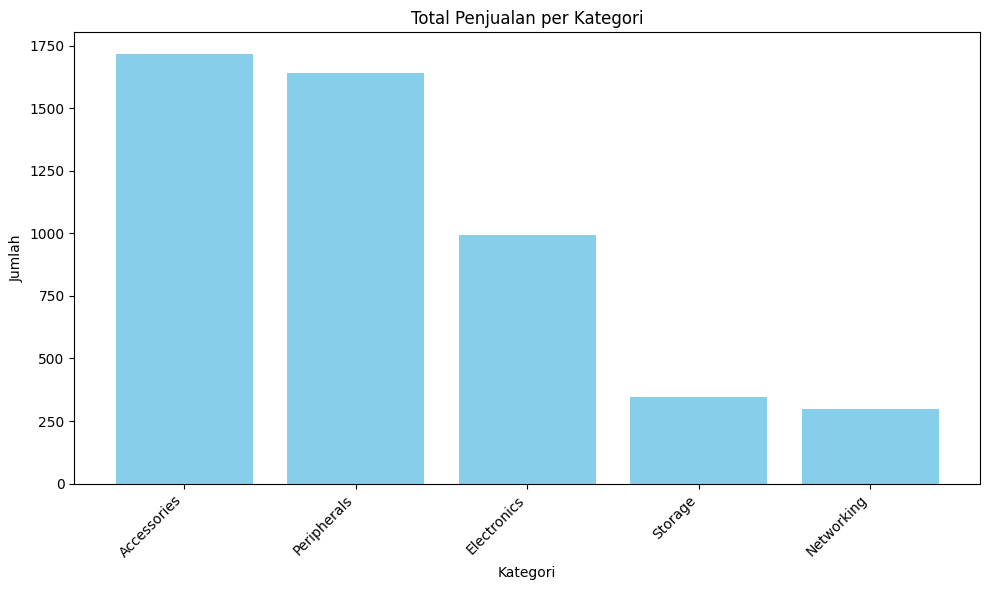

In [135]:
category = df['Category'].value_counts().sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 6)) # Ukuran
plt.bar(category.index, category.values, color='skyblue') # color warna
plt.xlabel('Kategori') # keterangan X label
plt.ylabel('Jumlah') # keterangan y label
plt.title('Total Penjualan per Kategori') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

Terlihat dari grafik tersebut menunjukkan bahwa kategori Accessories dan Peripherals memiliki tingkat penjualan yang cukup tinggi, lalu terdapat kategori yang tergolong rendah yaitu storage dam networking.

Tindakan yang harus dilakukan yaitu fokus pada peningkatan stok dan promosi pada kategori Storage dan Networking, dan untuk yang kategori lain cukup mempertahankan kualitas dan terus berkembang.

## Pie Chart

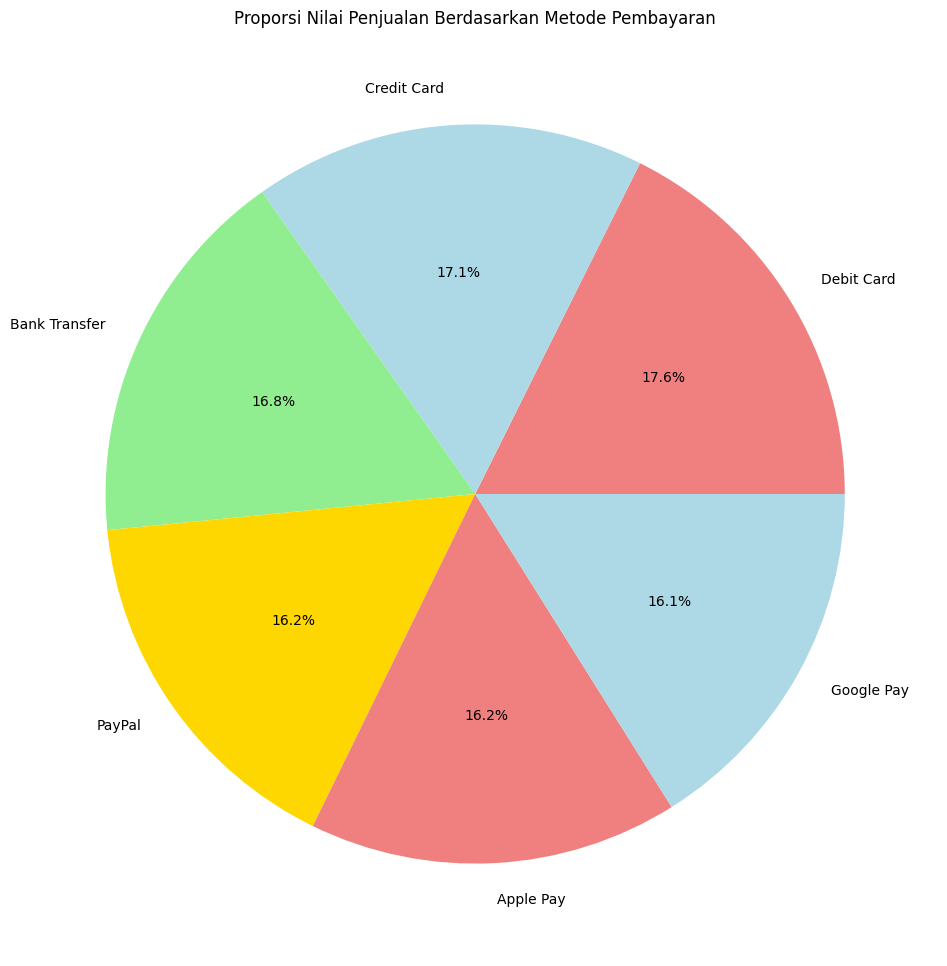

In [136]:
plt.figure(figsize=(18, 12)) # ukuran
plt.pie(df['Payment_Method'].value_counts(), labels=df['Payment_Method'].value_counts().index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'lightgreen', 'gold']) # colors (warna)
plt.title('Proporsi Nilai Penjualan Berdasarkan Metode Pembayaran') # Judul
plt.show()

Terlihat dari proporsi nilai penjualan berdasarkan cara pembayaran cukup merata. Tidak ada satupun cara pembayaran yang dominan.

Tindakan yang perlu dilakukan yaitu pertahankan semua metode pembayaran yang ada. Beri promo ringan pada metode pembayaran jika diperlukan.

## Line Chart

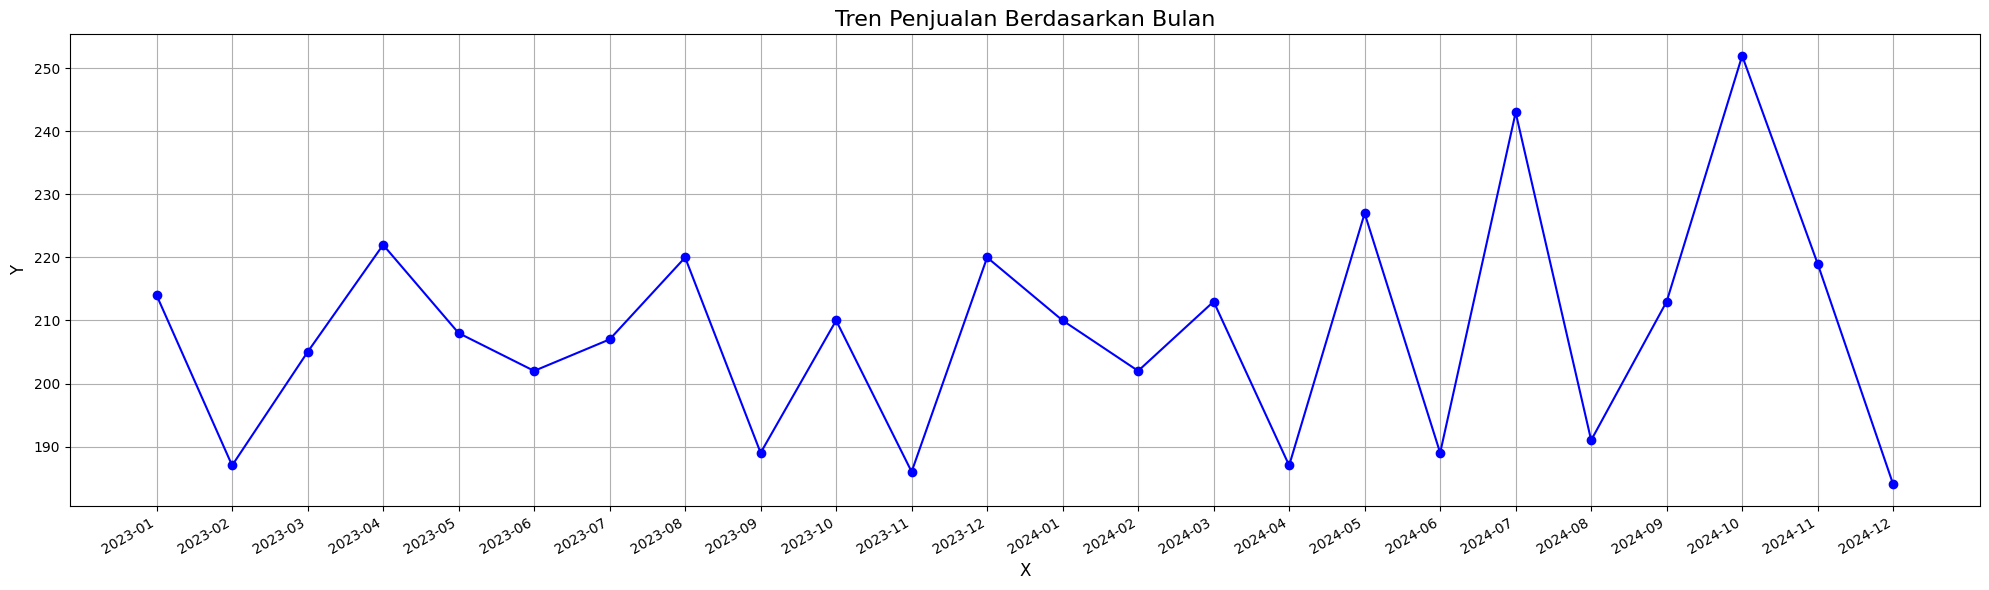

In [137]:
# Group by month
datemonth = df.groupby(df['Date'].dt.to_period('M')).size()

plt.figure(figsize=(20, 6)) # Ukuran figure diperbesar untuk kejelasan
plt.plot(datemonth.index.astype(str), datemonth.values, marker='o', color='blue') # Mengubah warna agar berbeda
plt.title('Tren Penjualan Berdasarkan Bulan', fontsize=16) # Judul
plt.xlabel('X', fontsize=12) # X Keterangan
plt.ylabel('Y', fontsize=12) # Y Keterangan
plt.grid(True)
plt.gcf().autofmt_xdate() # Otomatis mengatur format dan rotasi di sumbu X
plt.tight_layout()
plt.show()

Terlihat dari grafik tersebut tren penjualan per bulan cenderung tidak tetap, mengalami naik turun tiap bulannya dengan puncaknya terjadi pada Oktober 2024.

Tindakan yang perlu dilakukan yaitu mempelajari campaign, produk, ataupun event pada tren puncak penjualan lalu ulangi pola promosi dengan periode serupa. Siapkan juga stok lebih awal menjelang bulan dengan peforma tinggi.

## Histogram

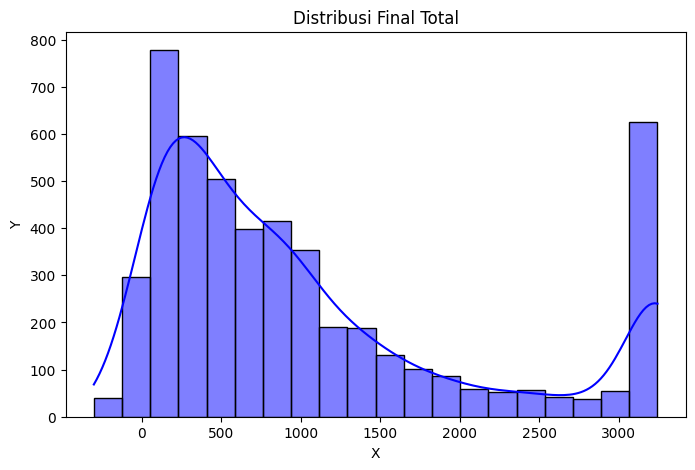

In [138]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Final_Total'], bins=20, kde=True, color='blue')
plt.title('Distribusi Final Total')
plt.xlabel('Frekuensi')
plt.ylabel('Final Total')
plt.show()

Terlihat pada grafik tersebut mayoritas transaksi berada pada nilai sekitar 200 sampai 1000. Ini menunjukkan sebagian besar pelanggan melakukan pembelian kecil sampai menengah. Lalu jumlah transaksi menurun setelah nilai sekitar 1000, artinya transaksi bernilai besar lebih sedikit. Terlihat juga puncak lain di sekitar 3000 sampai 3200. Ini menunjukkan ada transaksi bernilai tinggi dari produk mahal atau pembelian dalam jumlah banyak. Distribusi condong ke kanan. Banyak transaksi kecil. Sedikit transaksi besar.

Tindakan yang perlu dilakukan Tingkatkan nilai transaksi keci gunakanlah bundling produk dan rekomendasi produk tambahan. Fokus pada produk bernilai tinggi. Promosikan produk premium yang menghasilkan transaksi besar.



## BoxPlot

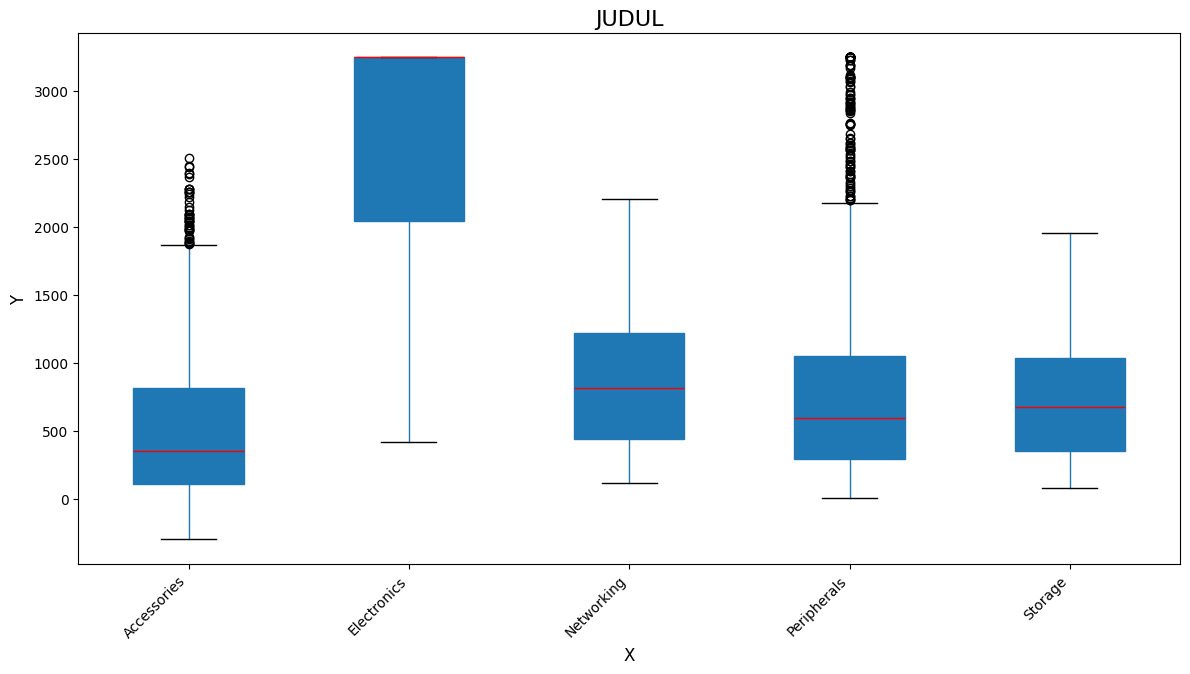

In [139]:
VARIABEL1 = df['Category'].value_counts().head(5).index
VARIABEL2 = df[df['Category'].isin(VARIABEL1)]

plt.figure(figsize=(12, 7)) # Ukuran figure
VARIABEL2.boxplot(column='Final_Total', by='Category', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red'))
plt.title('JUDUL', fontsize=16) # Judul
plt.xlabel('X', fontsize=12) # X Keterangan
plt.ylabel('Y', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.suptitle('') # Menghilangkan judul default dari boxplot.by
plt.tight_layout()
plt.show()

Terlihat dari grafik tersebut bahwa kategori Electronics memiliki sebaran dan median paling tinggi dan di beberapa katgori yaitu Peripherals dan Accessories memiliki outlier yang artinya terdapat transaksi besar tetapi tidak konsisten.

Tindakan yang perlu dilakukan Jangan terlalu bergantung pada diskon, lebih baik mengutamakan optimalisasi harga, bundling, kualitas produk, dan rekomendasi produk

## ScatterPlot

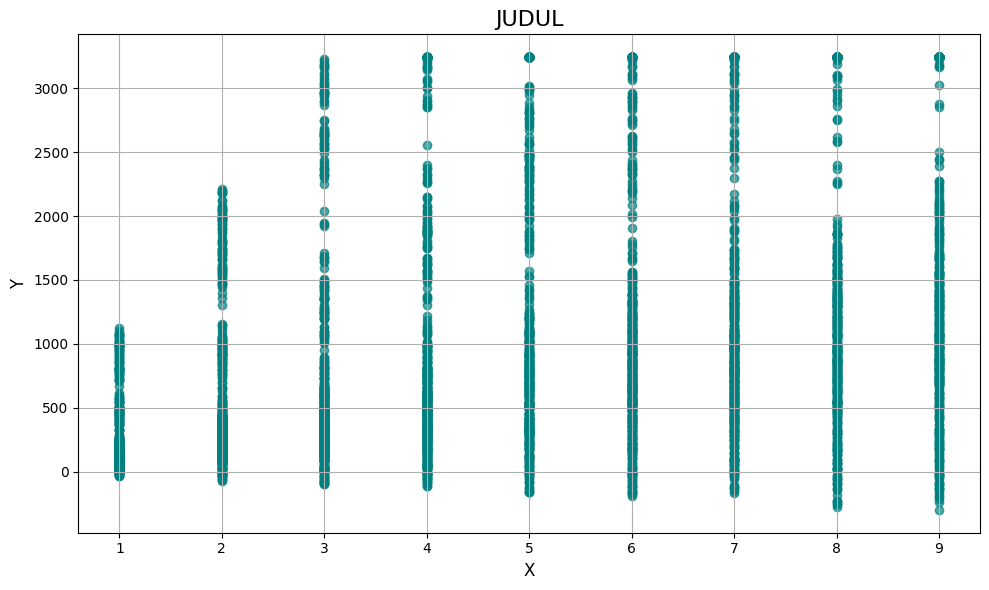

In [141]:
plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['Quantity'], df['Final_Total'], alpha=0.7, color='teal') # Color (Warna)
plt.title('JUDUL', fontsize=16) # Judul
plt.xlabel('X', fontsize=12) # X Keterangan
plt.ylabel('Y', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

Terlihat dari grafik tersebut semakin besar jumlah produk yang dibeli, nilai transaksi cenderung meningkat. Titik pada quantity 1 memiliki nilai transaksi paling rendah ini menunjukkan pembelian banyak item meningkatkan nilai transaksi. Sebaran titik cukup lebar. Artinya nilai transaksi juga dipengaruhi faktor lain seperti harga produk dan diskon.

Tindakan yang dapat dilakukan yaitu mendorong pembelian lebih dari satu produk. Gunakan strategi bundling atau paket hemat juga mempromosikan paket pembelian 3 sampai 5 produk karena terlihat menghasilkan transaksi lebih tinggi. Dan terakhir fokus pada strategi meningkatkan quantity karena quantity terbukti meningkatkan nilai transaksi.

## Heatmap

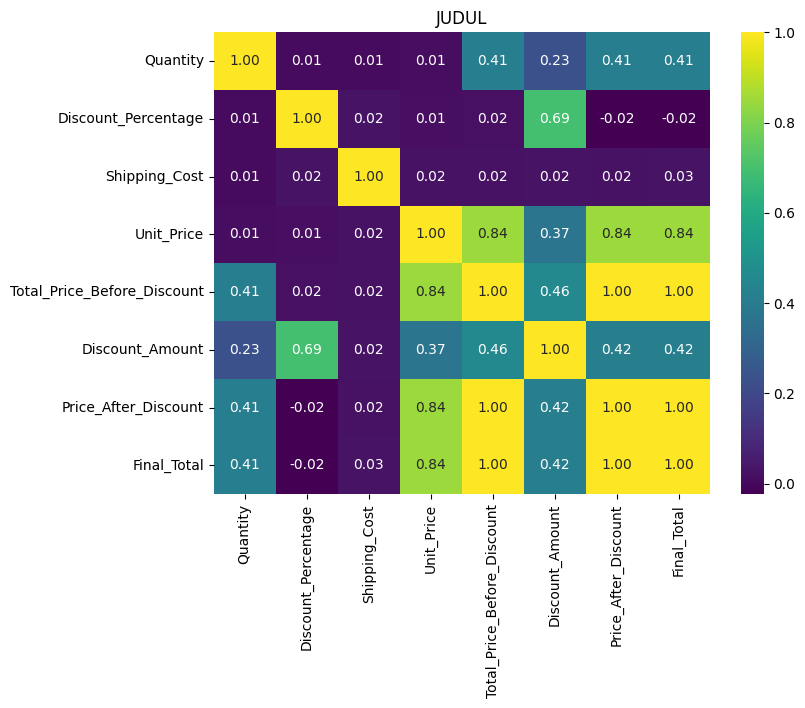

In [143]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Quantity', 'Discount_Percentage', 'Shipping_Cost', 'Unit_Price', 'Total_Price_Before_Discount', 'Discount_Amount', 'Price_After_Discount', 'Final_Total']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('JUDUL')
plt.show()

Terlihat pada grafik tersebut menunjukkan korelasi antar kolom numerik dengan:


*   Final_Total sangat dipengaruhi oleh Total_Price_Before_Discount dan Price_After_Discount dengan korelasi 1.00. Artinya nilai transaksi terutama ditentukan oleh harga total produk yang dibeli.

*   Unit_Price memiliki korelasi sangat kuat dengan Final_Total sebesar 0.84. Produk dengan harga lebih tinggi menghasilkan transaksi lebih besar.

*   Quantity memiliki korelasi sedang dengan Final_Total sebesar 0.41. Semakin banyak jumlah produk yang dibeli maka nilai transaksi meningkat.

*   Discount_Percentage hampir tidak berpengaruh pada Final_Total dengan korelasi sekitar -0.02. Diskon tidak secara langsung menaikkan nilai transaksi.

*   Shipping_Cost juga tidak memiliki pengaruh signifikan terhadap Final_Total dengan korelasi sekitar 0.03.

Tindakan yang perlu dilakukan yaitu dengan memfokuskan pada produk dengan harga unit tinggi karena harga produk menjadi faktor utama dalam pembentukan nilai transaksi. Evaluasi dan perbaiki penggunaan diskon agar lebih selektif karna terbukti tidak meningkatkan nilai transaksi secara langsung.